# Preprocessing, modeling, and evaluation using 4 algorithms

 Importing NumPy, Pandas, and Matplotlib



In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset

We load the **Student Performance** dataset from a CSV file into a Pandas DataFrame using the provided file path.


In [212]:
PATH = r"C:\Users\alsai\Downloads\archive\Student_Performance.csv"

df = pd.read_csv(PATH)
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


# Processing

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [214]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [215]:
df[df.astype(str).apply(lambda x: x.str.contains('\?')).any(axis=1)]

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
C:\Users\alsai\AppData\Local\Temp\ipykernel_13600\901282791.py:1: SyntaxWarning: invalid escape sequence '\?'
  df[df.astype(str).apply(lambda x: x.str.contains('\?')).any(axis=1)]


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [216]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [217]:
df['Hours Studied'].unique()

array([7, 4, 8, 5, 3, 6, 2, 1, 9])

In [218]:
df[df.astype(str).apply(lambda x: x.str.contains('\?')).any(axis=1)]

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
C:\Users\alsai\AppData\Local\Temp\ipykernel_13600\901282791.py:1: SyntaxWarning: invalid escape sequence '\?'
  df[df.astype(str).apply(lambda x: x.str.contains('\?')).any(axis=1)]


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [219]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [220]:
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


In [221]:
df.duplicated().sum()

np.int64(127)

In [222]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [223]:
df.drop_duplicates(inplace=True)

In [224]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [225]:
df.info

<bound method DataFrame.info of       Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      S

In [226]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [227]:
df[ 'Performance Index'].unique()

array([ 91.,  65.,  45.,  36.,  66.,  61.,  63.,  42.,  69.,  84.,  73.,
        27.,  33.,  68.,  43.,  67.,  70.,  30.,  71.,  85.,  57.,  35.,
        49.,  83.,  74.,  39.,  58.,  47.,  60.,  32.,  64.,  54.,  17.,
        53.,  75.,  52.,  78.,  38.,  98.,  87.,  41.,  81.,  15.,  88.,
        95.,  29.,  21.,  76.,  25.,  34.,  50.,  56.,  82.,  23.,  46.,
        92.,  77.,  86.,  44.,  94.,  40., 100.,  31.,  26.,  18.,  51.,
        72.,  16.,  28.,  89.,  48.,  37.,  62.,  59.,  19.,  79.,  22.,
        10.,  90.,  80.,  24.,  20.,  96.,  55.,  97.,  12.,  93.,  14.,
        99.,  11.,  13.])

In [228]:
df['Sleep Hours'].unique()

array([9, 4, 7, 5, 8, 6])

In [229]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

In [230]:
df['Previous Scores'].unique()

array([99, 82, 51, 52, 75, 78, 73, 45, 77, 89, 91, 79, 47, 72, 83, 54, 96,
       74, 85, 61, 62, 84, 94, 90, 44, 70, 67, 97, 59, 55, 68, 63, 46, 76,
       43, 81, 93, 98, 48, 92, 64, 88, 60, 87, 40, 69, 80, 95, 49, 50, 53,
       71, 56, 58, 66, 65, 57, 41, 42, 86])

In [231]:
df['Hours Studied'].unique()

array([7, 4, 8, 5, 3, 6, 2, 1, 9])

In [232]:
df.duplicated().sum()

np.int64(0)

In [233]:
df.drop_duplicates(inplace=True)

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


# Modeling 

Importing Scikit-Learn Modules for Regression Analysis

We import essential modules from `scikit-learn` to perform regression modeling:

- LinearRegression for building a linear regression model  
- PolynomialFeatures to create polynomial features for non-linear regression  
- train_test_split to split the dataset into training and testing sets  
- mean_absolute_error, mean_squared_error, and r2_score for model evaluation metrics

In [235]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [236]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

In [237]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [238]:
y = df['Performance Index']
X = df.drop(columns='Performance Index')

X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.2, random_state=42)


In [239]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = df['Performance Index']
X = df.drop(columns='Performance Index')

X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.2, random_state=42)

Linear Regression 

We initialize and train a `LinearRegression` model using the encoded training features `X_train_encoded` and the target variable `y_train`.

In [240]:
model = LinearRegression()
model.fit(X_train_encoded, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [241]:
y_predict = model.predict(X_test)

mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test,y_predict)

print("\nLinear Regression ")
print(f"mae : {mae:.2f}")
print(f"mse : {mse:.2f}")
print(f"rmse : {rmse:.2f}")
print(f"r2 : {r2:.2f}")


Linear Regression 
mae : 1.65
mse : 4.31
rmse : 2.08
r2 : 0.99


c:\Users\alsai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


Linear Regression: Model Evaluation Metrics

We evaluate the performance of the Linear Regressionmodel using the following metrics

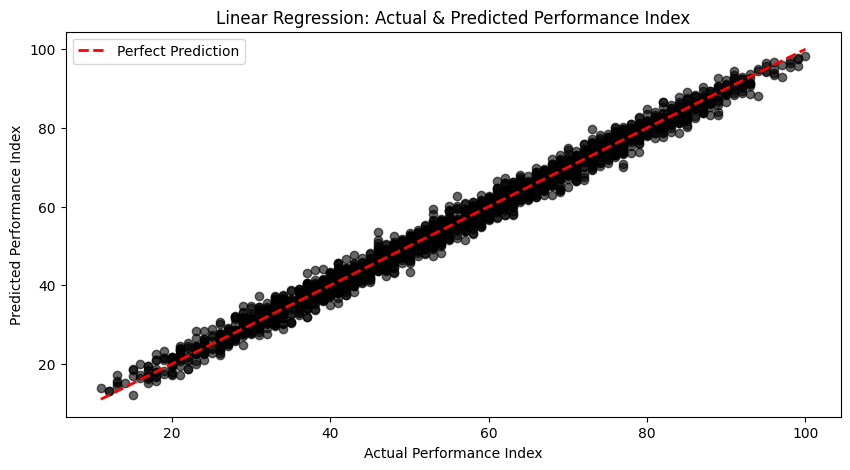

In [242]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_predict, color='black', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Linear Regression: Actual & Predicted Performance Index")
plt.legend()

plt.show()

 Polynomial Regression

To capture non-linear relationships, we transform the features using PolynomialFeatures

In [243]:
polynomial_regression = PolynomialFeatures(degree=2)
X_train_poly = polynomial_regression.fit_transform(X_train)
X_test_poly = polynomial_regression.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [244]:
np.sort(y_predict)

array([12.06131529, 13.00483359, 13.07974563, ..., 97.50595086,
       97.81615812, 98.36251517], shape=(1975,))

In [245]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)



In [246]:
print("\nPolynomial Regression")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")


Polynomial Regression
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.31
Root Mean Squared Error (RMSE): 2.07
R-squared (R2): 0.99


 Polynomial Regression: Actual & Predicted Performance Index

This scatter plot visualizes the predictions made by the polynomial regression model

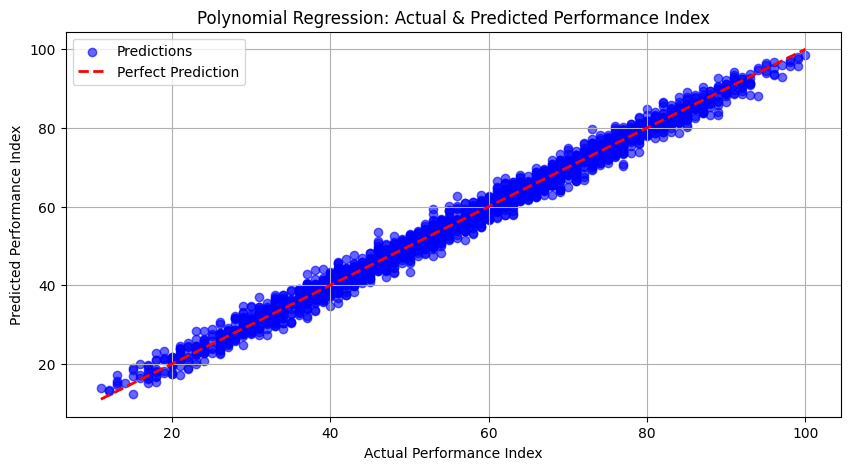

In [247]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_poly, color='blue', alpha=0.6, label='Predictions')
min_value = min(y_test.min(), y_pred_poly.min())
max_value = max(y_test.max(), y_pred_poly.max())
plt.plot([min_value, max_value], [min_value, max_value],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Polynomial Regression: Actual & Predicted Performance Index")
plt.legend()
plt.grid(True)

plt.show()



 Lasso Regression Results

In [248]:
from sklearn.linear_model import Lasso

In [249]:
lasso_reg = Lasso(alpha=0.1)
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


In [250]:
print("\nLasso Regression")
print(f"Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")


Lasso Regression
Mean Absolute Error (MAE): 1.67
Mean Squared Error (MSE): 4.41
Root Mean Squared Error (RMSE): 2.10
R-squared (R2): 0.99


Lasso Regression: Actual vs. Predicted Performance Index

This scatter plot visualizes the performance of the Lasso Regression model:

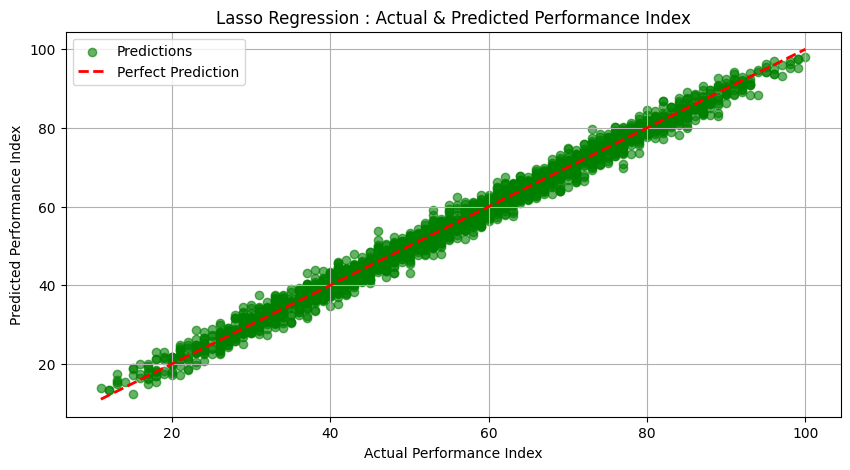

In [251]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_lasso, color='green', alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Lasso Regression : Actual & Predicted Performance Index")
plt.legend()
plt.grid(True)

plt.show()

Ridge Regression

In [252]:
from sklearn.linear_model import Ridge

In [253]:
ridge_reg = Ridge(alpha=1.0)

ridge_reg.fit(X_train, y_train)

ridge_predictions = ridge_reg.predict(X_test)

mae_ridge = mean_absolute_error(y_test, ridge_predictions)
mse_ridge = mean_squared_error(y_test, ridge_predictions)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, ridge_predictions)



In [254]:
print("\nRidge Regression")
print(f"Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")


Ridge Regression
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.31
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


 Ridge Regression: Actual & Predicted Performance Index

This scatter plot shows how the Ridge Regression model's predictions compare to the actual Performance Index values

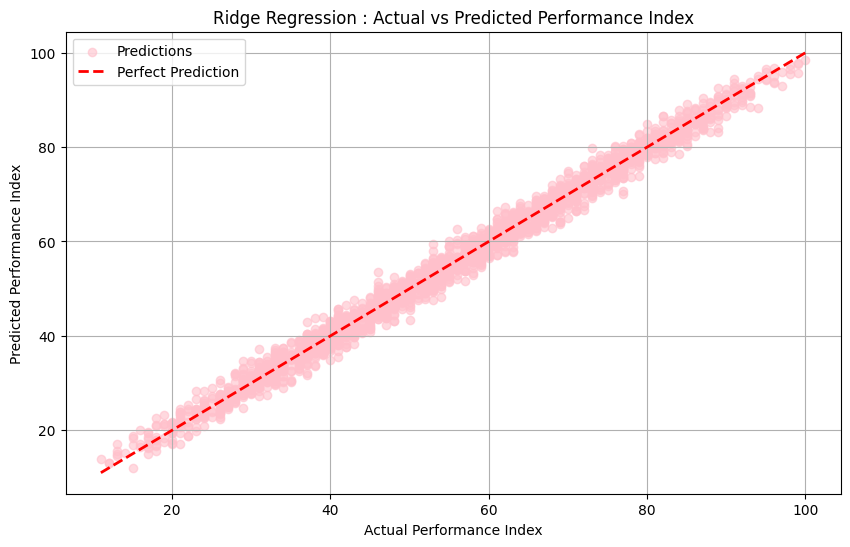

In [255]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, ridge_predictions, color='pink', alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Ridge Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

Decision Tree Regressor

In [256]:
from sklearn.tree import DecisionTreeRegressor

In [257]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

In [258]:
print("\nDecision Tree")
print(f"Mean Absolute Error (MAE): {dt_mae:.2f}")
print(f"Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {dt_rmse:.2f}")
print(f"R-squared (R2): {dt_r2:.2f}")


Decision Tree
Mean Absolute Error (MAE): 2.04
Mean Squared Error (MSE): 6.61
Root Mean Squared Error (RMSE): 2.57
R-squared (R2): 0.98


Decision Tree Regression: Actual & Predicted Performance Index

This scatter plot visualizes the predictions from the Decision Tree Regression model

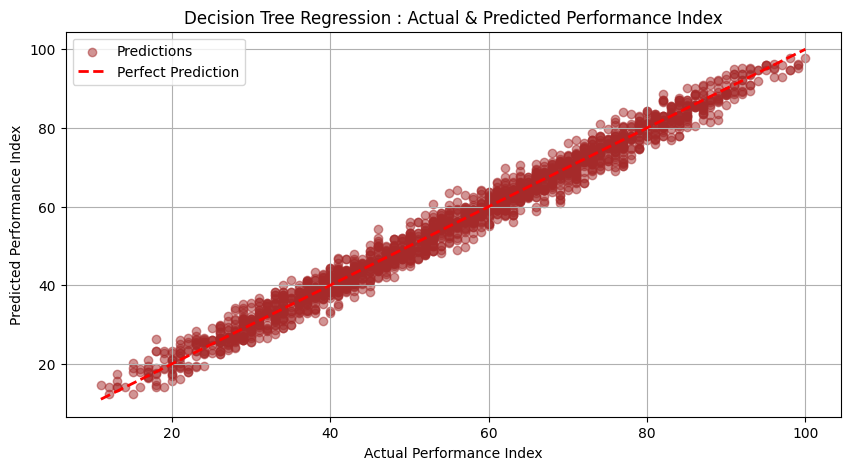

In [259]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, dt_predictions, color='brown', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Decision Tree Regression : Actual & Predicted Performance Index")
plt.legend()
plt.grid(True)

plt.show()

Random Forest Regresssion 

In [260]:
from sklearn.ensemble import RandomForestRegressor

In [261]:
random_forest = RandomForestRegressor(n_estimators=500, max_depth=None, random_state=42)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

mae_rf_value = mean_absolute_error(y_test, rf_predictions)
mse_rf_value = mean_squared_error(y_test, rf_predictions)
rmse_rf_value = np.sqrt(mse_rf_value)
r2_rf_value = r2_score(y_test, rf_predictions)



In [262]:
print("\nRandom Forest")
print(f"Mean Absolute Error (MAE): {mae_rf_value:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf_value:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_value:.2f}")
print(f"R-squared (R2): {r2_rf_value:.2f}")


Random Forest
Mean Absolute Error (MAE): 1.89
Mean Squared Error (MSE): 5.60
Root Mean Squared Error (RMSE): 2.37
R-squared (R2): 0.98


Random Forest Regression: Actual & Predicted Performance Index

This scatter plot displays the predictions made by the Random Forest Regression model

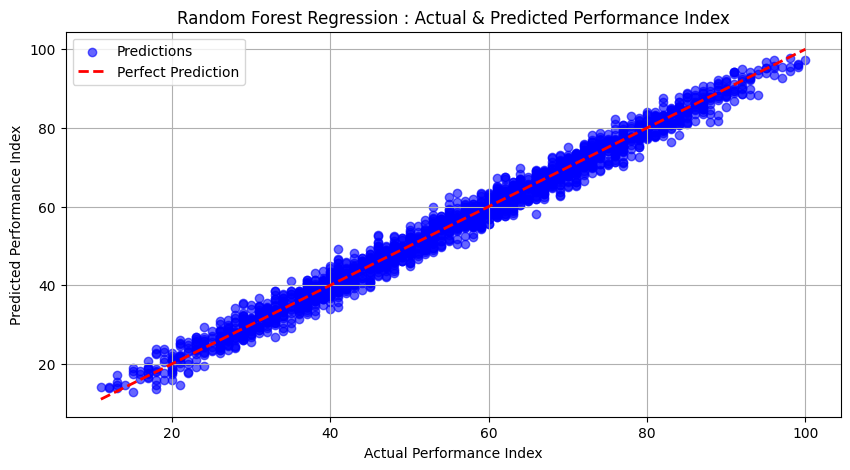

In [263]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, rf_predictions, color='blue', alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Random Forest Regression : Actual & Predicted Performance Index")
plt.legend()
plt.grid(True)

plt.show()

SVR Regression 

In [264]:
from sklearn.svm import SVR

In [265]:
svr_regressor = SVR(kernel='rbf', C=100, epsilon=0.1)

svr_regressor.fit(X_train, y_train)

svr_predictions = svr_regressor.predict(X_test)

mae_svr_val = mean_absolute_error(y_test, svr_predictions)
mse_svr_val = mean_squared_error(y_test, svr_predictions)
rmse_svr_val = np.sqrt(mse_svr_val)
r2_svr_val = r2_score(y_test, svr_predictions)



In [266]:
print("\nSVM Regression")
print(f"Mean Absolute Error (MAE): {mae_svr_val:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr_val:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr_val:.2f}")
print(f"R-squared (R2): {r2_svr_val:.2f}")


SVM Regression
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.34
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


Support Vector Regression (SVR): Actual & Predicted Performance Index

This scatter plot illustrates the performance of the Support Vector Regression (SVR) model

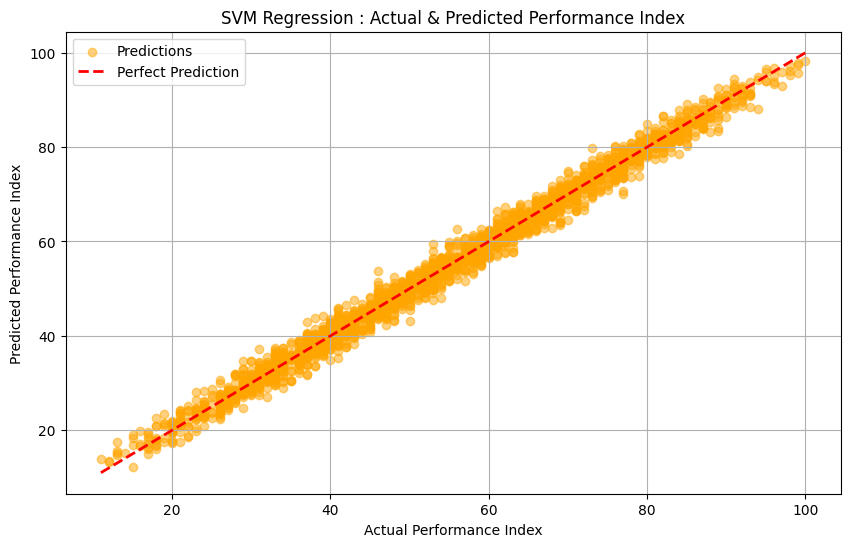

In [267]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, svr_predictions, color='Orange', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("SVM Regression : Actual & Predicted Performance Index")
plt.legend()
plt.grid(True)

plt.show()